In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/placement.csv')

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [5]:
df = df.iloc[:,1:]

In [6]:
df.head()

,placement_exam_marks,placed
0,26.0,1
1,38.0,1
2,40.0,1
3,8.0,1
4,17.0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   placement_exam_marks  1000 non-null   float64
 1   placed                1000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


In [8]:
df.shape

(1000, 2)

In [9]:
df = df.iloc[:,1:]

In [10]:
df.head()

,placed
0,1
1,1
2,1
3,1
4,0


In [11]:
import matplotlib.pyplot as plt

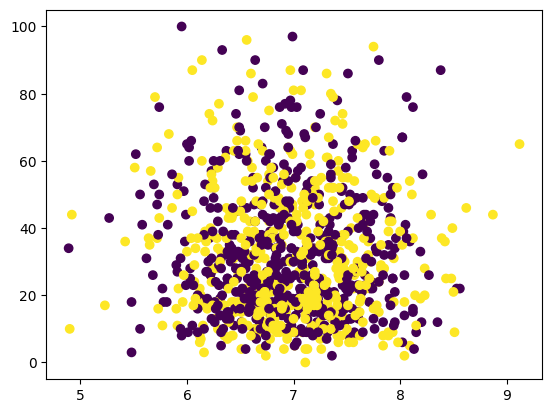

In [12]:
df = pd.read_csv('/content/placement.csv')
plt.scatter(df['cgpa'], df['placement_exam_marks'], c=df['placed'])

In [13]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [14]:
x

,cgpa,placement_exam_marks
0,7.19,26.0
1,7.46,38.0
2,7.54,40.0
3,6.42,8.0
4,7.23,17.0
...,...,...
995,8.87,44.0
996,9.12,65.0
997,4.89,34.0
998,8.62,46.0


In [15]:
y.shape

(1000,)

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1)

In [17]:
x_train

,cgpa,placement_exam_marks
897,7.13,35.0
444,6.66,14.0
89,6.56,17.0
493,6.80,18.0
154,7.57,54.0
...,...,...
112,7.23,15.0
368,7.09,32.0
81,7.12,44.0
214,7.42,60.0


In [18]:
y_train

,placed
897,1
444,1
89,0
493,0
154,1
...,...
112,0
368,0
81,1
214,1


In [19]:
x_test

,cgpa,placement_exam_marks
268,7.38,21.0
947,6.49,70.0
238,7.41,78.0
546,6.75,18.0
335,6.90,17.0
...,...,...
765,6.55,28.0
130,5.91,53.0
396,7.28,10.0
809,6.39,22.0


In [20]:
y_test

,placed
268,0
947,0
238,0
546,1
335,1
...,...
765,0
130,0
396,1
809,1


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
x_train = scaler.fit_transform(x_train)

In [24]:
x_train

array([[ 0.28084793,  0.16220916],
       [-0.48673412, -0.95995526],
       [-0.65004945, -0.79964606],
       ...,
       [ 0.2645164 ,  0.64313677],
       [ 0.75446238,  1.49811919],
       [ 1.94666429, -1.22713727]])

In [25]:
x_test = scaler.transform(x_test)

In [26]:
x_test

array([[ 6.89136252e-01, -5.85900452e-01],
       [-7.64370180e-01,  2.03248320e+00],
       [ 7.38130850e-01,  2.45997441e+00],
       [-3.39750324e-01, -7.46209655e-01],
       [-9.47773295e-02, -7.99646056e-01],
       [-1.18899004e+00, -5.15364402e-02],
       [ 1.06476151e+00, -1.01339166e+00],
       [ 2.56726254e+00, -5.32464050e-01],
       [-6.21142636e-02,  2.40653801e+00],
       [ 1.95434011e-02,  1.65842840e+00],
       [-5.52060252e-01, -6.92773254e-01],
       [ 1.40772370e+00,  1.62209164e-01],
       [-3.23418791e-01, -4.25591248e-01],
       [ 1.79968049e+00,  2.69081967e-01],
       [ 1.19541377e+00,  3.75954769e-01],
       [-1.12366390e+00, -8.53082457e-01],
       [ 5.58483988e-01, -4.79027649e-01],
       [-1.85858289e+00,  4.82827571e-01],
       [-9.76680108e-01,  1.55155559e+00],
       [-1.10733237e+00,  1.39124639e+00],
       [-8.62359378e-01,  6.43136775e-01],
       [-4.57827307e-02,  1.97904680e+00],
       [-1.27440395e-01,  1.62209164e-01],
       [-1.

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
clf = LogisticRegression()

In [29]:
clf.fit(x_train, y_train)

LogisticRegression()

In [30]:
y_pred = clf.predict(x_test)

In [31]:
y_test

,placed
268,0
947,0
238,0
546,1
335,1
...,...
765,0
130,0
396,1
809,1


In [32]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy_score(y_test, y_pred)

0.5

In [34]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

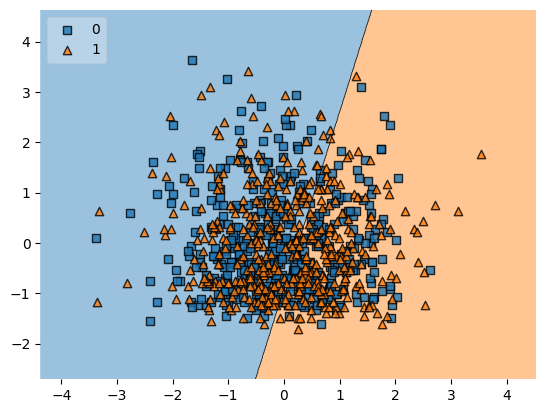

In [35]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend =2)

In [36]:
import pickle

In [37]:
pickle.dump(clf,open('model.pkl' , 'wb'))